---
title: Transmission Dither Locking, Pound-Drever-Hall Michelson, and Fabry-Perot Michelson  - Homework 04
date: 2025-04-06
authors:
  - name: Breck Meagher 
    orcid: 0009-0009-0293-3406
    affiliations:
      - Syracuse University
numbering:
  heading_1: true
  heading_2: true
  heading_3: true
---

This is the fourth homework assignment for *Lasers and Optomechanics* at Syracuse University.\
**It is due Monday, April 6th, 2026 by 5 pm**

**<span style="color:#ff5555;">You will need to complete the questions in this jupyter notebook and submit it via `gitlab`</span>**


In [12]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sympy as sp

plt.style.use('dark_background')
fontsize = 14
mpl.rcParams.update(
    {
        "text.usetex": False,
        "figure.figsize": (9, 6),
        "figure.autolayout": False,
        "font.family": "serif",
        #"font.serif": "DejaVu Serif",
        # 'mathtext.fontset': 'cm',
        "lines.linewidth": 1.5,
        "font.size": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fancybox": True,
        "legend.fontsize": fontsize,
        "legend.framealpha": 0.7,
        "legend.handletextpad": 0.5,
        "legend.labelspacing": 0.2,
        "legend.loc": "best",
        "axes.edgecolor": "#b0b0b0",
        "grid.color": "#707070",  # grid color"
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "savefig.dpi": 80,
        "pdf.compression": 9,
    }
)

## **Transmitted Field Dither Locking**

In class, we investigated dither locking using the reflected field $E_\mathrm{refl}$ from a Fabry-Perot cavity.

In this problem, investigate whether it is possible to use $E_\mathrm{trans}$ to hold lock.


### **Plot of Fabry-Perot $E_\mathrm{refl}$ versus $E_\mathrm{trans}$**

Plot both $E_\mathrm{refl}$ and $E_\mathrm{trans}$ over a span of $\phi \in \left[ -\dfrac{\pi}{2},\dfrac{3\pi}{2} \right]$

Do you notice anything different about the resonance points?

---
Transmission is always maximized and reflection is minimized at $\phi=0$ (resonance), but the critically coupled case has 0 reflected field at resonance.

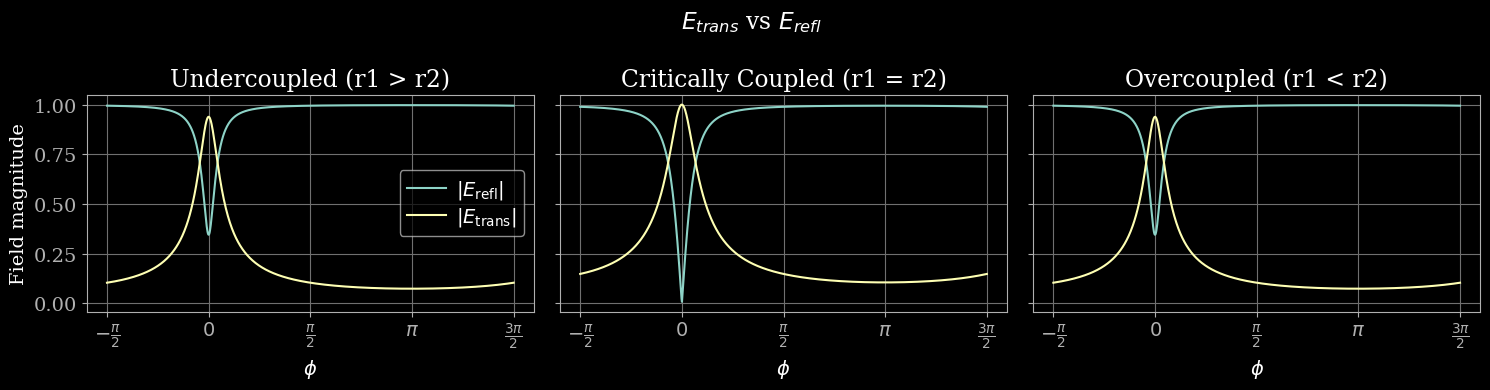

In [13]:
plt.close('all')

# phi range
phi = np.linspace(-np.pi/2, 3*np.pi/2, 1000)
E_in = 1.0

def compute_fields(r1, r2):
    """
    compute E_trans and E_refl
    """
    t1 = np.sqrt(1 - r1**2)
    t2 = np.sqrt(1 - r2**2)
    
    den = 1 - r1 * r2 * np.exp(-1j * phi)
    
    E_refl = (r1 - (t1**2 * r2 * np.exp(-1j * phi)) / den) * E_in
    E_trans = (t1 * t2 * np.exp(-1j * phi / 2) / den) * E_in
    
    return np.abs(E_refl), np.abs(E_trans)

# define coupling
cases = {
    "Undercoupled (r1 > r2)": (0.95, 0.9),
    "Critically Coupled (r1 = r2)": (0.9, 0.9),
    "Overcoupled (r1 < r2)": (0.9, 0.95),
}

# custom pi ticks
pi_ticks = [-np.pi/2, 0, np.pi/2, np.pi, 3*np.pi/2]
pi_labels = [
    r'$-\frac{\pi}{2}$',
    r'$0$',
    r'$\frac{\pi}{2}$',
    r'$\pi$',
    r'$\frac{3\pi}{2}$'
]

# plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (title, (r1, r2)) in zip(axes, cases.items()):
    E_refl, E_trans = compute_fields(r1, r2)
    
    ax.plot(phi, E_refl, label=r'$|E_{\mathrm{refl}}|$')
    ax.plot(phi, E_trans, label=r'$|E_{\mathrm{trans}}|$')
    
    ax.set_title(title)
    ax.set_xlabel(r'$\phi$')
    ax.set_xticks(pi_ticks)
    ax.set_xticklabels(pi_labels)
    ax.grid(True)

axes[0].set_ylabel('Field magnitude')
axes[0].legend()

plt.suptitle(r'$E_{trans}$ vs $E_{refl}$')
plt.tight_layout()
plt.show()

### **Total $E_\mathrm{trans}$ with end-mirror moduation**  

If we apply an end-mirror modulation $\Delta x \cos(\omega t)$ to our Fabry-Perot cavity, 
what is the total $E_\mathrm{trans}(t)$ field?

---
When the end mirror is modulated as
$$
x(t) = x_0 + \Delta x \cos(\omega t)
$$
the cavity length becomes time-dependent. Define phase as:
$$
\phi(t) = kL(t)
$$

Then:
$$
\phi(t) = k\big(L + \Delta x \cos(\omega t)\big) = \phi_0 + k\Delta x \cos(\omega t)
$$


1. On the beam's first pass through the cavity (before encountering the end mirror):

$$
\frac{E_\mathrm{cav}}{E_\mathrm{in}} = \frac{t_1 e^{-i\phi}}{1 - r_1 r_2 e^{-2i\phi}}
$$  


2. Modulations are induced at the end mirror ($\pm \omega$):  

$$
E_\mathrm{cav}^{\pm} = \pm i k \Delta x \, E_\mathrm{cav} \, e^{\pm i \omega t}
$$

3. Propagate fields to transmission:  
The sidebands now interact with the input mirror, then head back to (and through) the end mirror once again:
$$
E_\mathrm{trans}^0 = t_2 E_\mathrm{cav}, \quad
E_\mathrm{trans}^{\pm} = E_\mathrm{cav}^{\pm} \frac{-r_1 t_2 e^{-2 i (\phi \pm \eta)}}{1 - r_1 r_2 e^{-2 i (\phi \pm \eta)}}, \quad
\eta = \frac{\omega L}{c}.
$$

4. Total transmitted field:  
Summing carrier and sidebands gives  

$$
\begin{aligned}
E_\mathrm{trans}(t) &= E_\mathrm{trans}^0 + E_\mathrm{trans}^+ + E_\mathrm{trans}^- \\
&= \boxed{E_0 e^{i \omega_0 t} \frac{t_1 t_2 e^{-i \phi}}{1 - r_1 r_2 e^{-2 i \phi}}
\left[ 1 + i k \Delta x e^{i \omega t} \frac{r_1 r_2 e^{-2 i (\phi + \eta)}}{1 - r_1 r_2 e^{-2 i (\phi + \eta)}} + i k \Delta x e^{-i \omega t} \frac{r_1 r_2 e^{-2 i (\phi - \eta)}}{1 - r_1 r_2 e^{-2 i (\phi - \eta)}} \right]}
\end{aligned}
$$

I think...

---

### **Calculate the total transmitted power $P_\mathrm{trans}(t)$**

Calculate $P_\mathrm{trans}(t) = |E_\mathrm{trans}(t)|^2$

You may set $\Delta x^2 = 0$ for simplicity in the calculations.  
You should end up with only DC and 1$\omega$ terms.

You may leave this power term in a general form if you wish, 
but you must be clear what each of the contributing fields are.

---

The transmitted field takes the form:
$$
E_\mathrm{trans}(t) = E_0 + E_+ + E_-
$$

where $E_0$ is the unmodulated carrier and $E_\pm$ are the $\pm \omega$ sidebands, linear in $\Delta x$.  
  
Compute transmitted power:
$$
P_\mathrm{trans}(t) = |E_\mathrm{trans}(t)|^2 = |E_0 + E_+ + E_-|^2
$$

Expanding the modulus squared:
$$
\begin{aligned}
P_\mathrm{trans}(t) &= |E_0|^2 + |E_+|^2 + |E_-|^2 \\
&\quad + E_0 E_+^* + E_0^* E_+ + E_0 E_-^* + E_0^* E_- \\
&\quad + E_+ E_-^* + E_+^* E_-
\end{aligned}
$$

Since $E_\pm \sim \mathcal{O}(\Delta x)$, terms quadratic in the sidebands ($|E_\pm|^2$ and $E_+ E_-^*$) are $\mathcal{O}(\Delta x^2)$ and can be neglected. This leaves
$$
P_\mathrm{trans}(t) \approx |E_0|^2 + E_0 E_+^* + E_0^* E_+ + E_0 E_-^* + E_0^* E_-
$$
  

The **DC component** should come from the carrier:
$$
P_\mathrm{DC} = |E_0|^2 = E_0^2 \frac{t_1^2 t_2^2}{|1 - r_1 r_2 e^{-2 i \phi}|^2} 
= E_0^2 \frac{t_1^2 t_2^2}{1 + r_1^2 r_2^2 - 2 r_1 r_2 \cos(2\phi)}
$$

The **$\omega$ component** should come from interference between the carrier and sidebands:
$$
P_{1\omega}(t) = E_0 E_+^* + E_0^* E_+ + E_0 E_-^* + E_0^* E_-
$$

This can be expressed by defining complex amplitude
$$
Z = E_0^* E_+ + E_0 E_-^*
$$

so that
$$
P_{1\omega}(t) = Z e^{i \omega t} + Z^* e^{-i \omega t} = 2 \, \mathrm{Re}[Z e^{i \omega t}]
$$

Using the cavity transfer functions for the sidebands:
$$
E_+ = i k \Delta x \frac{r_1 r_2 e^{-2 i (\phi + \eta)}}{1 - r_1 r_2 e^{-2 i (\phi + \eta)}} E_0, \quad
E_- = i k \Delta x \frac{r_1 r_2 e^{-2 i (\phi - \eta)}}{1 - r_1 r_2 e^{-2 i (\phi - \eta)}} E_0
$$

with $\eta = \omega L / c$, we find

$$
Z = i k \Delta x E_0^2 \left[ \frac{r_1 r_2 e^{-2 i (\phi + \eta)}}{1 - r_1 r_2 e^{-2 i (\phi + \eta)}} - \frac{r_1 r_2 e^{2 i (\phi - \eta)}}{1 - r_1 r_2 e^{2 i (\phi - \eta)}} \right]
$$

The transmitted power is then:
$$
\boxed{P_\mathrm{trans}(t) \approx P_\mathrm{DC} + 2 \, \mathrm{Re}[Z e^{i \omega t}]}
$$

---

### **Calculate the transmitted power demodulated at $\omega$** 
Calculate the demodulated term $P_\mathrm{trans}(\omega) = P^I_\mathrm{trans}(\omega) + i P^Q_\mathrm{trans}(\omega)$.
This should be directly proportional to $\Delta x$.

---
The demodulated component is obtained by projecting the transmitted power onto $e^{i \omega t}$:
$$
P_\mathrm{trans}(\omega) = \frac{1}{2\pi} \int_0^{2\pi} P_\mathrm{trans}(t) \, e^{i \omega t} \, d(\omega t)
$$

Since $P_\mathrm{trans}(t) = P_\mathrm{DC} + 2 \mathrm{Re}[Z e^{i \omega t}]$, the integral picks out only the terms linear in $e^{-i \omega t}$:
$$
P_\mathrm{trans}(\omega) = Z^*
$$

where $Z$ is the complex amplitude of the $\omega$-frequency term from the previous step.

Using the carrier and sideband fields:

$$
\begin{aligned}
E_0 &= E_0 e^{i \omega_0 t} \frac{t_1 t_2 e^{-i \phi}}{1 - r_1 r_2 e^{-2 i \phi}}, \\
E_+ &= i k \Delta x E_0 e^{i (\omega_0 + \omega) t} \frac{r_1 r_2 e^{-2 i (\phi + \eta)}}{1 - r_1 r_2 e^{-2 i (\phi + \eta)}} \\
E_- &= i k \Delta x E_0 e^{i (\omega_0 - \omega) t} \frac{r_1 r_2 e^{-2 i (\phi - \eta)}}{1 - r_1 r_2 e^{-2 i (\phi - \eta)}}
\end{aligned}
$$

with $\eta = \omega L / c$.  
  
The demodulated power is therefore
$$
P_\mathrm{trans}(\omega) = E_0 E_+^* + E_- E_0^*.
$$

Substituting the explicit forms of the fields:
$$
\boxed{
P_\mathrm{trans}(\omega) = i k \Delta x E_0^2 \frac{t_1^2 t_2^2 r_1 r_2}{1 + r_1^2 r_2^2 - 2 r_1 r_2 \cos(2\phi)}
\left[ \frac{e^{-2 i (\phi - \eta)}}{1 - r_1 r_2 e^{-2 i (\phi - \eta)}} - \frac{e^{2 i (\phi + \eta)}}{1 - r_1 r_2 e^{2 i (\phi + \eta)}} \right]
}
$$

Which is proportional to $\Delta x$ !

---

### **Plot the length to transmitted power function phase sweep**
Plot the real and imaginary parts of $\dfrac{P_\mathrm{trans}(\omega)}{\Delta x}$ over $\phi \in \left[ -\dfrac{\pi}{2},\dfrac{3\pi}{2} \right]$

Choosing some low to moderate finesse cavity parameters, 
plot your derived function $\dfrac{P_\mathrm{trans}}{\Delta x}(\omega)$ as a function of carrier phase $\phi$.

Let the cavity parameters be
$$L = 1~\mathrm{m}\\ P_\mathrm{in} = 1~\mathrm{W}\\ T_1 = 0.3\\ T_2 = 0.3\\ \lambda = 1064~\mathrm{nm}\\ \omega = 2 \pi (100~\mathrm{Hz})$$

---

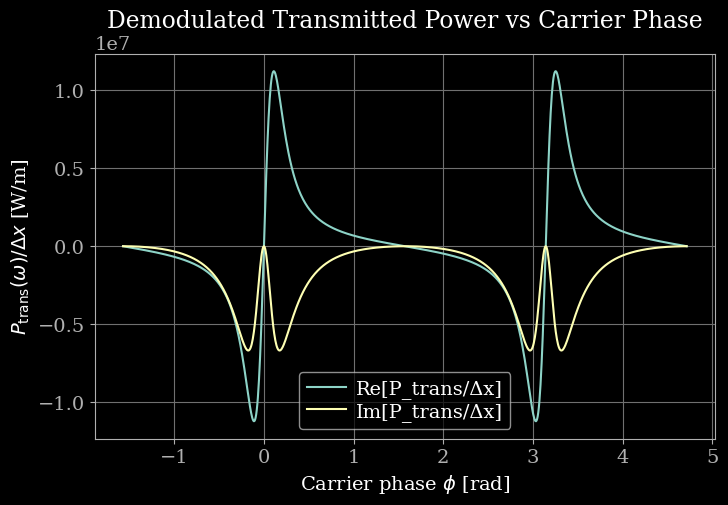

In [15]:
# cav params
L = 1.0                # cavity length [m]
Pin = 1.0              # input power [W]
T1 = 0.3               # input mirror transmissivity
T2 = 0.3               # end mirror transmissivity
R1 = 1 - T1            # input mirror reflectivity
R2 = 1 - T2            # end mirror reflectivity
lam = 1064e-9          # wavelength [m]
c = 3e8                # speed of light [m/s]
k = 2 * np.pi / lam    # wavenumber
omega_mod = 2 * np.pi * 100  # modulation frequency [Hz]

# sideband phase shift
eta = omega_mod * L / c

# carrier phase sweep
phi = np.linspace(-np.pi/2, 3*np.pi/2, 1000)  # carrier phase

def P_trans_over_DeltaX(phi):
    # cavity denominator
    denom0 = 1 - np.sqrt(R1*R2) * np.exp(-2j*phi)
    
    # sideband denominators
    denom_plus  = 1 - np.sqrt(R1*R2) * np.exp(-2j*(phi + eta))
    denom_minus = 1 - np.sqrt(R1*R2) * np.exp(-2j*(phi - eta))
    
    # numerator factor
    prefac = 1j * k * Pin * np.sqrt(T1*T2) * np.sqrt(R1*R2) / np.abs(denom0)**2
    
    # full demodulated power (linear in Delta x)
    P_demod = prefac * (np.exp(-2j*(phi - eta))/denom_minus - np.exp(2j*(phi + eta))/denom_plus)
    
    return P_demod

# compute function
P_demod = P_trans_over_DeltaX(phi)

# plot
plt.figure(figsize=(8,5))
plt.plot(phi, P_demod.real, label='Re[P_trans/Δx]')
plt.plot(phi, P_demod.imag, label='Im[P_trans/Δx]')
plt.xlabel(r'Carrier phase $\phi$ [rad]')
plt.ylabel(r'$P_\mathrm{trans}(\omega)/\Delta x$ [W/m]')
plt.title('Demodulated Transmitted Power vs Carrier Phase')
plt.legend()
plt.grid(True)
plt.show()

### **Plot the length to transmitted power transfer function**

Plot your transfer function magnitude and phase $\dfrac{P_\mathrm{trans}}{\Delta x}(\omega)$ as a function of frequency $f = \omega / (2\pi)$.

Use the same cavity parameters as above, but allow $f \in [3 \times 10^3, 3 \times 10^8]~\mathrm{Hz}$, while setting $\phi = 1^{\circ}$.

---

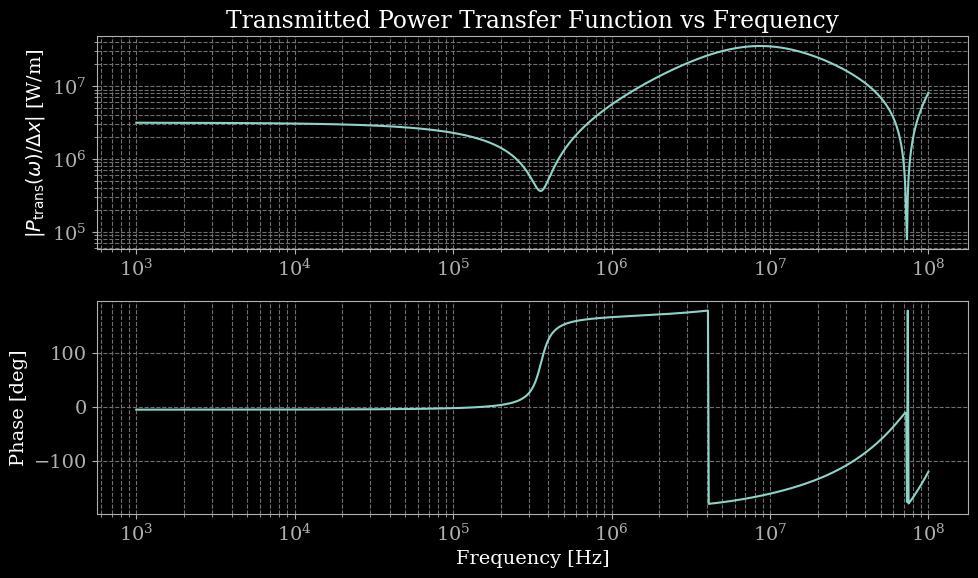

In [19]:
# carrier phase
phi = np.deg2rad(1)    # 1 degree in radians

# frequencies
f = np.logspace(3, 8, 1000)   # Hz
omega_mod = 2 * np.pi * f     # rad/s

P_demod = P_trans_over_DeltaX_freq(phi, omega_mod)

# plot
plt.figure(figsize=(10,6))

# magnitude
plt.subplot(2,1,1)
plt.loglog(f, np.abs(P_demod))
plt.ylabel(r'$|P_\mathrm{trans}(\omega)/\Delta x|$ [W/m]')
plt.title('Transmitted Power Transfer Function vs Frequency')
plt.grid(True, which='both', ls='--')

# phase
plt.subplot(2,1,2)
plt.semilogx(f, np.angle(P_demod, deg=True))
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'Phase [deg]')
plt.grid(True, which='both', ls='--')

plt.tight_layout()
plt.show()

## **Pound-Drever-Hall Michelson**

In-class we went over the Pound-Drever-Hall (PDH) Fabry-Perot interferometer.

Now we'll try to apply the same technique lock a Michelson interferometer to it's carrier dark fringe.

Below is a diagram of a Michelson with carrier at $\omega_0$, 
and two RF phase sidebands created by an electro-optic modulator (EOM)
oscillating at $\Omega$ to create two frequencies $\omega_0 \pm \Omega$.\
Our goal is to calculate the PDH error signal $\epsilon_\mathrm{PDH}$ as a function of the carrier phase offset $\phi_d$ and RF sideband frequency $\Omega$.


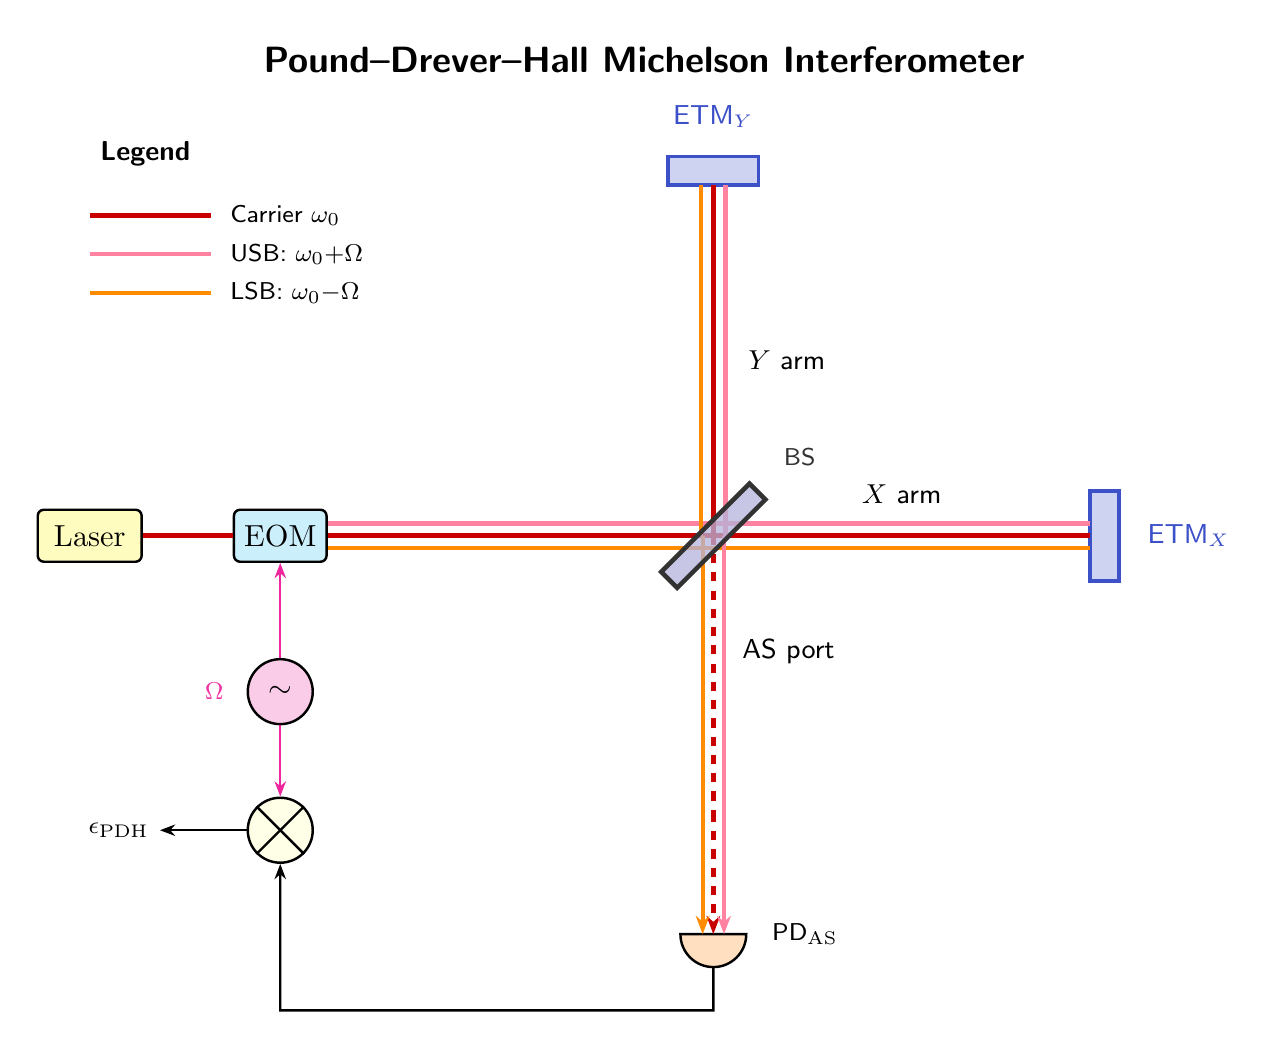

---

### **Calculate the total dark field $E_{as}(t)$**

Calculate the full field expression $E_{as}(t)$ at the dark port of the interferometer.

There should be three contributions, one from carrier and two from the RF phase sidebands injected alongside the carrier.

Let the modulation depth of the RF sideband be $\Gamma$.\
Let the carrier differential phase be $\phi_d = \omega_0 (L_x - L_y) / c$,\
and the RF phase differential phase be $\varphi_d = \Omega (L_x - L_y) / c$.\

What happens to our phases and $E_{as}(t)$ if $L_x = L_y$ exactly?

*Hint: The RF sidebands will experience a phase shift of $\phi_d \pm \varphi_d$ as it transmitted through the interferometer*

---

The input field including RF phase modulation is
$$
E_\mathrm{in}(t) = E_0 e^{i \omega_0 t} \left[ 1 + i \frac{\Gamma}{2} e^{i \Omega t} + i \frac{\Gamma}{2} e^{-i \Omega t} \right]
$$

The first term is the carrier, and the next two terms are the upper and lower sidebands linearized in $\Gamma$.  
  
Each arm introduces a phase shift:
$$
\begin{aligned}
\text{Carrier: } & \phi_c \pm \phi_d = \omega_0 \frac{L_x + L_y}{c} \pm \omega_0 \frac{L_x - L_y}{c} \\
\text{Sidebands: } & (\omega_0 \pm \Omega) \frac{L_x \pm L_y}{c} \implies \text{phase shifts } \phi_c \pm \varphi_c, \phi_d \pm \varphi_d
\end{aligned}
$$

Assuming the beam splitter has amplitude reflectivity $ r_{bs} $ and transmissivity $ t_{bs} $, and end mirrors are identical $ r_x = r_y = r_e $, the dark port transfer function for a field at frequency $ \omega $ is
$$
\frac{E_{as}}{E_\mathrm{in}}(\omega) = r_{bs} t_{bs} r_e \left[ e^{-2 i \omega L_y / c} - e^{-2 i \omega L_x / c} \right].
$$

Using trigonometric identities:

$$
\frac{E_{as}}{E_\mathrm{in}}(\omega) = -2 i r_{bs} t_{bs} r_e e^{- i \omega (L_x + L_y)/c} \sin \big( \omega (L_x - L_y)/c \big).
$$

Substituting the carrier and sidebands into the transfer function:

$$
\begin{aligned}
E_{as}(t) &= E_0 e^{i \omega_0 t} \Bigg[ 
\frac{E_{as}}{E_\mathrm{in}}(\omega_0) 
+ i \frac{\Gamma}{2} e^{i \Omega t} \frac{E_{as}}{E_\mathrm{in}}(\omega_0 + \Omega) 
+ i \frac{\Gamma}{2} e^{-i \Omega t} \frac{E_{as}}{E_\mathrm{in}}(\omega_0 - \Omega) 
\Bigg] \\
&= \boxed{-2 i E_0 r_{bs} t_{bs} r_e e^{i \omega_0 t} e^{- i \phi_c} \Big[ 
\sin \phi_d 
+ i \frac{\Gamma}{2} e^{i \Omega t} e^{-i \varphi_c} \sin(\phi_d + \varphi_d) 
+ i \frac{\Gamma}{2} e^{-i \Omega t} e^{i \varphi_c} \sin(\phi_d - \varphi_d) 
\Big]}
\end{aligned}
$$

Here:

- First term: carrier contribution to AS port  
- Second/third terms: upper and lower RF sidebands  


If $ L_x = L_y $, then
$$
\phi_d = \varphi_d = 0 \implies \boxed{E_{as}(t) = 0}
$$

so the dark port is perfectly dark.

---

### **Calculate the total dark power $P_{as}(t)$**

Calculate $P_{as}(t) = |E_{as}(t)|^2$.

Assume that the second order modulation terms $\Gamma^2 = 0$, for simplicity.

---

Expand $|E_{as}(t)|^2$ (keep only linear terms in $\Gamma$):

$$
P_{as}(t) = 4 E_0^2 r_{bs}^2 t_{bs}^2 r_e^2 
\Big| \sin\phi_d + i \frac{\Gamma}{2} e^{i\Omega t} e^{-i\varphi_c} \sin(\phi_d + \varphi_d) + i \frac{\Gamma}{2} e^{-i\Omega t} e^{i\varphi_c} \sin(\phi_d - \varphi_d) \Big|^2
$$

The cross terms between the carrier and sidebands give:
$$
\begin{aligned}
P_{as}(t) &\approx 4 E_0^2 r_{bs}^2 t_{bs}^2 r_e^2 \Big[
\sin^2 \phi_d + i \frac{\Gamma}{2} e^{i\Omega t} e^{-i\varphi_c} \sin\phi_d \big( \sin(\phi_d + \varphi_d) - \sin(\phi_d - \varphi_d) \big) \\
&\quad + i \frac{\Gamma}{2} e^{-i\Omega t} e^{i\varphi_c} \sin\phi_d \big( \sin(\phi_d - \varphi_d) - \sin(\phi_d + \varphi_d) \big)
\Big]
\end{aligned}
$$

Using the identity:
$$
\sin(A \pm B) = \sin A \cos B \pm \cos A \sin B
$$

$$
\sin(\phi_d + \varphi_d) - \sin(\phi_d - \varphi_d) = 2 \cos\phi_d \sin\varphi_d
$$

Substitute:
$$
\boxed{
P_{as}(t) \approx 4 E_0^2 r_{bs}^2 t_{bs}^2 r_e^2 \sin^2\phi_d 
\Big[ 1 - i \frac{\Gamma}{2} e^{-i\Omega t} e^{i\varphi_c} \sin\varphi_d + i \frac{\Gamma}{2} e^{i\Omega t} e^{-i\varphi_c} \sin\varphi_d \Big]
}
$$

---

### **Calculate the dark power demodulated at $\Omega$**

Calculate and plot the phase sweep of $\dfrac{P_{as}}{\Gamma}(\phi_d, \varphi_d)$ for $\phi_d \in [-5\pi, 5\pi]$.
for some assumed cavity parameters:

$$L_x = 5~\mathrm{m}\\
L_y = 5~\mathrm{m}\\
\Omega = 2 \pi (10~\mathrm{MHz})\\
r_\mathrm{bs} = t_\mathrm{bs} = \dfrac{1}{\sqrt{2}}\\
r_x = r_y = 1
$$

What do you notice about this signal $\dfrac{P_{as}}{\Gamma}(\phi_d, \varphi_d)$ as we increase the offset $\phi_d$?

---

Extract the component at frequency $\Omega$ using:

$$
P_{as}(\Omega) = \frac{1}{2\pi} \int_0^{2\pi} P_{as}(t) e^{i\Omega t} d(\Omega t)
$$

- The **DC term** and the term proportional to $e^{i\Omega t}$ integrate to zero.  
- Only the coefficient of $e^{-i\Omega t}$ contributes.

This gives:
$$
P_{as}(\phi_d, \varphi_d) = -2 i k E_0^2 r_{bs}^2 t_{bs}^2 r_x^2 \sin^2 \phi_d \, e^{i\varphi_c} \sin \varphi_d
$$

Assuming:
$$
r_{bs} = t_{bs} = \frac{1}{\sqrt{2}}, \quad r_x = r_y = 1, \quad P_\mathrm{in} = E_0^2
$$

rewrite in normalized form:
$$
\boxed{\frac{P_{as}}{P_\mathrm{in}} = - i k \frac{\Gamma}{2} \sin^2 \phi_d \, e^{i \varphi_c} \sin \varphi_d}
$$

If we have macroscopic arm lengths $L_x^0 = L_y^0 = 5~\mathrm{m}$ and a small differential change $\delta L$:
$$
L_x = L_x^0 + \frac{\delta L}{2}, \quad L_y = L_y^0 - \frac{\delta L}{2},
$$

then
$$
\phi_d = \frac{\omega_0 \delta L}{c}, \quad \varphi_d = \frac{\Omega \delta L}{c}.
$$

This allows us to sweep $\phi_d$ while keeping the RF sideband phase $\varphi_d$ proportional to $\delta L$.
  
Observation:

- The demodulated signal scales as $k \, \sin^2 \phi_d \, \sin \varphi_d$.  
- As $\phi_d$ moves away from 0, the magnitude of the demodulated signal increases in amplitude at its maxima.
- The argument has a clear crossover at resonance.

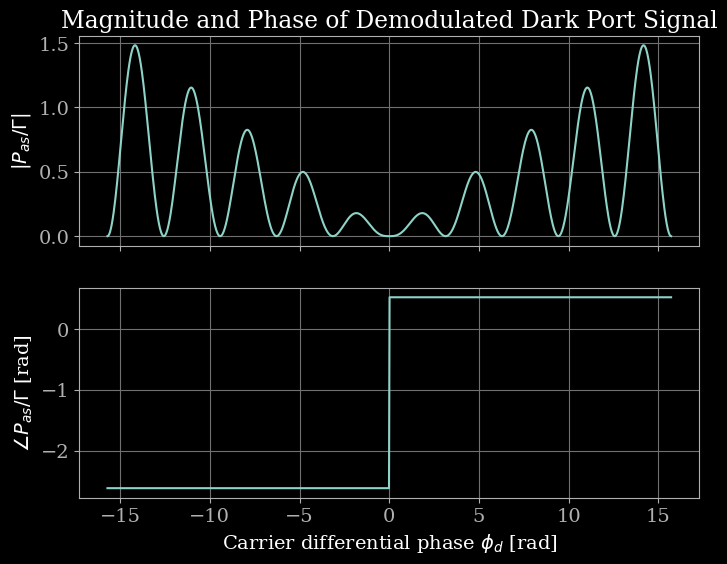

In [47]:
# constants
lam = 1064e-9          # wavelength [m]
c = 3e8                # speed of light [m/s]
k = 2 * np.pi / lam
omega0 = 2* np.pi * c / lam
Omega  = 2 * np.pi * 10e6
c = 3e8
Gamma = 1.0
E0 = 1.0
k = omega0 / c # carrier wavenumber

phi = np.linspace(-5*np.pi, 5*np.pi, 1000) # sweep from -5pi to 5pi
phi_len = phi / k                          # length change from phi input
phi_d = k * (Lx - Ly + phi_len)            # carrier DARM
phi_c = k * (Lx + Ly)                      # carrier CARM

varphi_d = Omega * (Lx - Ly + phi_len) / c # sideband DARM phase
varphi_c = Omega * (Lx + Ly) / c # sideband CARM phase

# demodulated dark port
P_demod = -1j * (k/2) * np.sin(phi_d)**2 * np.sin(varphi_d) * np.exp(1j * varphi_c)

# magnitude and phase
P_mag   = np.abs(P_demod)
P_phase = np.angle(P_demod)

# Plot magnitude and phase on separate subplots
fig, ax = plt.subplots(2, 1, figsize=(8,6), sharex=True)

ax[0].plot(phi_d, P_mag)
ax[0].set_ylabel(r'$|P_{as}/\Gamma|$')
ax[0].set_title('Magnitude and Phase of Demodulated Dark Port Signal')
ax[0].grid(True)

ax[1].plot(phi_d, P_phase)
ax[1].set_ylabel(r'$\angle P_{as}/\Gamma$ [rad]')
ax[1].set_xlabel(r'Carrier differential phase $\phi_d$ [rad]')
ax[1].grid(True)

plt.show()

## **Fabry-Perot Michelson Interferometer (FPMI)**

We investigated *compound interferometers* in class when we studied the coupled-cavity.\
Here we combine our Michelson interferometer with Fabry-Perot interferometers forming the arms,
forming the Fabry-Perot Michelson Interferometer (FPMI) in a configuration similar to LIGO.


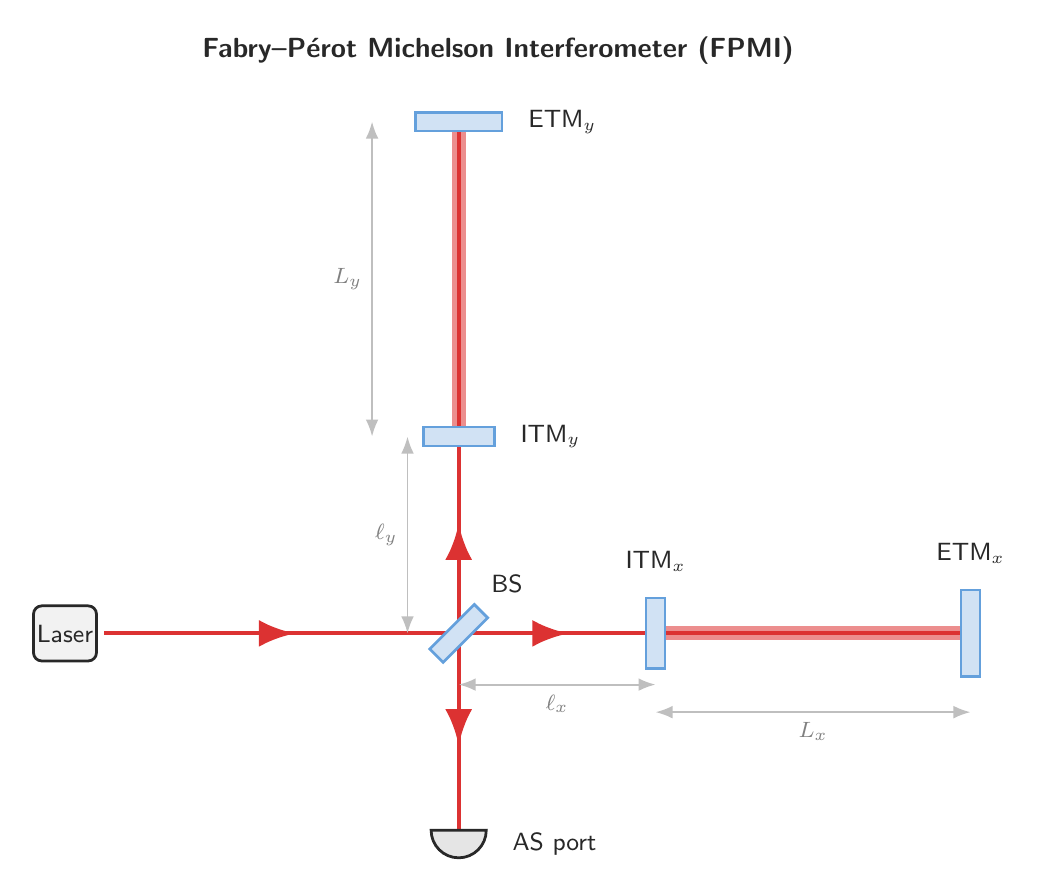

---

### **Adjacency Matrix**

Form an adjacency matrix for the FPMI interferometer.

I recommend using $\phi_x = k \ell_x$ and $\phi_y = k \ell_y$ for the short Michelson arms,\
and $\Phi_x = k L_x$ and $\Phi_y = k L_y$ for the Fabry-Perot arm lengths.

---

$$
\begin{bmatrix}
E_{in} \\
E^x_{in} \\
E^y_{in} \\
E^x_{cav} \\
E^y_{cav} \\
E^x_{cav2} \\
E^y_{cav2} \\
E^x_{refl} \\
E^y_{refl} \\
E_{as} \\
\end{bmatrix} =
\begin{bmatrix}
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
t_{bs} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
-r_{bs} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & t_{itmx} e^{-i\phi_x} & 0 & 0 & 0 & -r_{itmx} e^{-i\Phi_x} & 0 & 0 & 0 & 0 \\
0 & 0 & t_{itmy} e^{-i\phi_y} & 0 & 0 & 0 & -r_{itmy} e^{-i\Phi_y} & 0 & 0 & 0 \\
0 & 0 & 0 & -r_{etmx} e^{-i\Phi_x} & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & -r_{etmy} e^{-i\Phi_y} & 0 & 0 & 0 & 0 & 0 \\
0 & r_{itmx} e^{-i\phi_x} & 0 & 0 & 0 & t_{itmx} e^{-i\Phi_x} & 0 & 0 & 0 & 0 \\
0 & 0 & r_{itmy} e^{-i\phi_y} & 0 & 0 & 0 & t_{itmy} e^{-i\Phi_y} & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & r_{bs} e^{-i\phi_x} & t_{bs} e^{-i\phi_y} & 0 \\
\end{bmatrix} 
\begin{bmatrix}
E_{in} \\
E^x_{in} \\
E^y_{in} \\
E^x_{cav} \\
E^y_{cav} \\
E^x_{cav2} \\
E^y_{cav2} \\
E^x_{refl} \\
E^y_{refl} \\
E_{as} \\
\end{bmatrix}
$$

I'm definitely getting better at this... hope this is right!

---

### **Antisymmetric Port Field Derivations**

Find the $\dfrac{E_\mathrm{as}}{E_\mathrm{in}}$ transfer function by inverting the adjacency matrix.

You may also derive the FPMI response by using the compound interferometer technique, 
by letting the common Michelson X-arm reflection $r_x \rightarrow r_\mathrm{FP}(\Phi_x) = \dfrac{E_\mathrm{refl}}{E_\mathrm{in}}$.\
Does this derivation agree with your result from the adjacency matrix?

---

Fabry-perot reflection coefficients:
$$
r_\mathrm{FP}(\Phi_i) = \frac{r_{itmi} - r_{etmi} e^{-2 i \Phi_i}}{1 - r_{itmi} r_{etmi} e^{-2 i \Phi_i}}, \quad i = x, y
$$

Compound interferometer technique (I think I'm ignoring coupling between the X and Y arms...?):
\begin{align*}
r_x &\to r_\mathrm{FP}(\Phi_x), \\
r_y &\to r_\mathrm{FP}(\Phi_y), \\
E_\mathrm{as} &= t_{bs} \, r_\mathrm{FP}(\Phi_y) \, e^{-i \phi_y} \, E_\mathrm{in} + r_{bs} \, r_\mathrm{FP}(\Phi_x) \, e^{-i \phi_x} \, E_\mathrm{in}
\end{align*}

Inverted adjacency matrix:
\begin{align}
(I - A)^{-1} =
\begin{bmatrix}
* & * & * & \cdots & * \\
* & * & * & \cdots & * \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
\frac{r_{bs} r_\mathrm{FP}(\Phi_x) e^{-i\phi_x}}{1 - r_\mathrm{FP}(\Phi_x) r_\mathrm{FP}(\Phi_y) e^{-i(\phi_x+\phi_y)}} & 
\frac{t_{bs} r_\mathrm{FP}(\Phi_y) e^{-i\phi_y}}{1 - r_\mathrm{FP}(\Phi_x) r_\mathrm{FP}(\Phi_y) e^{-i(\phi_x+\phi_y)}} & \cdots & \cdots & *
\end{bmatrix}
\end{align}

Or:
$$
\boxed{
\frac{E_\mathrm{as}}{E_\mathrm{in}} = 
\frac{t_{bs} \, r_\mathrm{FP}(\Phi_y) \, e^{-i \phi_y} + r_{bs} \, r_\mathrm{FP}(\Phi_x) \, e^{-i \phi_x}}
{1 - r_\mathrm{FP}(\Phi_x) \, r_\mathrm{FP}(\Phi_y) \, e^{-i (\phi_x + \phi_y)}}}
$$

So the answers do not agree.

### **Simplifications to $E_\mathrm{as}$**

At this point, you may simplify $E_\mathrm{as}$ and change the basis using 
\begin{align}
\Phi_x &= \Phi_c + \Phi_d\\
\Phi_y &= \Phi_c - \Phi_d\\
\phi_x &= 0\\
\phi_y &= 0\\
r_\mathrm{bs} = t_\mathrm{bs} &= \dfrac{1}{\sqrt{2}}\\
r_\mathrm{itmx} &= r_\mathrm{itmy}\\
r_\mathrm{etmx} &= r_\mathrm{etmy}
\end{align}
The above assumes the short Michelson is always perfectly tuned, and the beamsplitter is ideal, and the Fabry-Perot arms are ideally balanced.

---

Full transfer function:
$$
\frac{E_\mathrm{as}}{E_\mathrm{in}} = 
\frac{t_{bs} \, r_\mathrm{FP}(\Phi_y) \, e^{-i \phi_y} + r_{bs} \, r_\mathrm{FP}(\Phi_x) \, e^{-i \phi_x}}
{1 - r_\mathrm{FP}(\Phi_x) \, r_\mathrm{FP}(\Phi_y) \, e^{-i (\phi_x + \phi_y)}}
$$

Apply Symmetry Assumptions:
\begin{align*}
\Phi_x &= \Phi_c + \Phi_d \\
\Phi_y &= \Phi_c - \Phi_d \\
\phi_x &= 0, \quad \phi_y = 0 \\
r_{bs} &= t_{bs} = \frac{1}{\sqrt{2}} \\
r_{itmx} &= r_{itmy}, \quad r_{etmx} = r_{etmy}
\end{align*}

This implies:
$$
r_\mathrm{FP}(\Phi_x) = r_\mathrm{FP}(\Phi_c + \Phi_d) \quad
r_\mathrm{FP}(\Phi_y) = r_\mathrm{FP}(\Phi_c - \Phi_d)
$$

Simplified expression:
$$
\frac{E_\mathrm{as}}{E_\mathrm{in}} =
\frac{1}{\sqrt{2}} \,
\frac{
r_\mathrm{FP}(\Phi_c - \Phi_d) + r_\mathrm{FP}(\Phi_c + \Phi_d)
}{
1 - r_\mathrm{FP}(\Phi_c + \Phi_d)\, r_\mathrm{FP}(\Phi_c - \Phi_d)
}
$$

For small $\Phi_d$, expand to first order:

\begin{align*}
r_\mathrm{FP}(\Phi_c \pm \Phi_d)
&\approx r_\mathrm{FP}(\Phi_c) \pm \Phi_d \, \frac{d r_\mathrm{FP}}{d\Phi}\Big|_{\Phi_c}
\end{align*}

Then:
\begin{align*}
r_\mathrm{FP}(\Phi_c - \Phi_d) + r_\mathrm{FP}(\Phi_c + \Phi_d)
&\approx 2 r_\mathrm{FP}(\Phi_c)
\end{align*}

and
\begin{align*}
r_\mathrm{FP}(\Phi_c + \Phi_d)\, r_\mathrm{FP}(\Phi_c - \Phi_d)
&\approx r_\mathrm{FP}(\Phi_c)^2
\end{align*}

So:
$$
\boxed{
\frac{E_\mathrm{as}}{E_\mathrm{in}} \approx 
\frac{\sqrt{2} \, r_\mathrm{FP}(\Phi_c)}
{1 - r_\mathrm{FP}(\Phi_c)^2}
}
$$

At perfect tuning ($\Phi_d = 0$), the antisymmetric port should be dark.  
This requires:
$$
r_\mathrm{FP}(\Phi_c + \Phi_d) = -\,r_\mathrm{FP}(\Phi_c - \Phi_d)
$$

which leads to:
$$
E_\mathrm{as} \propto \Phi_d
$$

---

### **Interpretation**

Plot the real and imaginary parts of $\dfrac{E_\mathrm{as}}{E_\mathrm{in}}$ as a function of $\Phi_d$.

Compare to the normal Michelson solution for the AS port.\
Do the Fabry-Perot arms enhance our sensitivity to differential displacement $\Phi_d$?

You may substitute in a moderate finesse Fabry-Perot cavity values
\begin{align}
\ell_x = \ell_y &= 5~\mathrm{m}\\
L_x = L_y &= 4000~\mathrm{m}\\
T_\mathrm{etmx} = T_\mathrm{etmy} &= 0\\
T_\mathrm{itmx} = T_\mathrm{itmy} &= 10\% \\
\end{align}

---

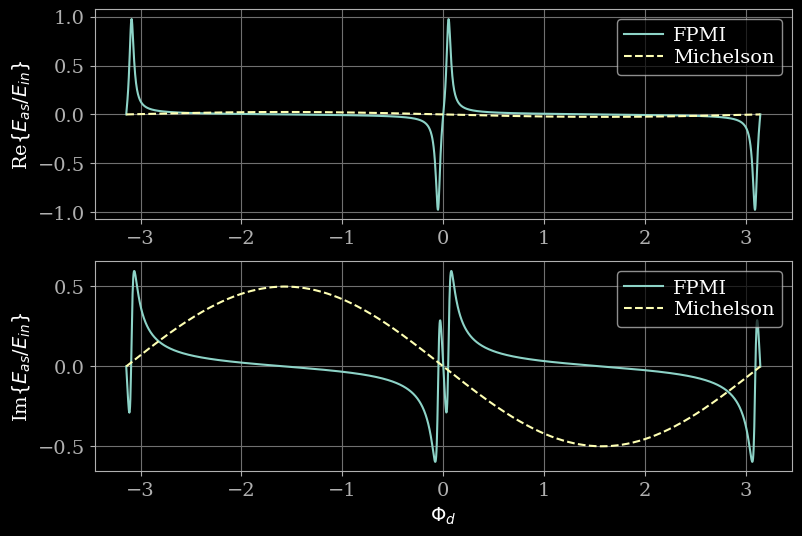

In [70]:
T_itm = 0.10
R_itm = 1 - T_itm
r_itm = np.sqrt(R_itm)

r_etm = 1.0

# transmissions
t_itm = np.sqrt(1 - r_itm**2)
t_etm = np.sqrt(1 - r_etm**2)

# beamsplitter
r_bs = 1 / np.sqrt(2)
t_bs = 1 / np.sqrt(2)

# slightly detuned from resonance
Phi_c = 0.05

# differential phase range
Phi_d = np.linspace(-np.pi, np.pi, 2000)

# fabry-perot michelson
num = r_etm * t_itm**2 * 1j * np.exp(-2j * Phi_c) * np.sin(2 * Phi_d)

den = (
    r_etm**2 * r_itm**2
    - 2 * r_etm * r_itm * np.exp(2j * Phi_c) * np.cos(2 * Phi_d)
    + np.exp(4j * Phi_c)
)

E_as_FPMI = num / den

# simple michelson
E_as_Mich = -1j * r_bs * t_bs * np.exp(-1j * Phi_c) * np.sin(Phi_d)

# plotting
# (devious)
fig, ax = plt.subplots(2)

# real part
ax[0].plot(Phi_d, np.real(E_as_FPMI), label='FPMI')
ax[0].plot(Phi_d, np.real(E_as_Mich), linestyle='--', label='Michelson')
ax[0].set_ylabel(r'Re$\{E_{as}/E_{in}\}$')
ax[0].grid()
ax[0].legend()

# imaginary part
ax[1].plot(Phi_d, np.imag(E_as_FPMI), label='FPMI')
ax[1].plot(Phi_d, np.imag(E_as_Mich), linestyle='--', label='Michelson')
ax[1].set_ylabel(r'Im$\{E_{as}/E_{in}\}$')
ax[1].set_xlabel(r'$\Phi_d$')
ax[1].grid()
ax[1].legend()

plt.show()